# Test Tseeded_functions Without Parallel Execution

This notebook tests the `compute_single_combination` function from `utils/Tseeded_functions.py` using input parameters from `inputs/config_test.py`, as in `main.py`. No parallel execution is used.

In [1]:
# 1. Import Required Libraries and Modules
import numpy as np
import importlib
from utils.Tseeded_functions import compute_single_combination

# Import config_test from inputs
config_module = importlib.import_module("inputs.config_test")

In [2]:
# 2. Load Input Parameters from config_test
# Extract all relevant fields and convert units as in main.py
V_plasma = config_module.V_plasma_field.data.to('m^3').magnitude
T_i = config_module.T_i_field.data.to('keV').magnitude
n_tot = config_module.n_tot_field.data.to('1/m^3').magnitude
tau_p_T = config_module.tau_p_T_field.data.to('s').magnitude
P_aux = config_module.P_aux_field.data.to('W').magnitude
P_aux_DT_eq = config_module.P_aux_DT_eq_field.data.to('W').magnitude
TBR_DT = config_module.TBR_DT_field.data.to_base_units().magnitude
TBR_DDn = config_module.TBR_DDn_field.data.to_base_units().magnitude
tau_ifc = config_module.tau_ifc_field.data.to('s').magnitude
tau_ofc = config_module.tau_ofc_field.data.to('s').magnitude
eta_th = config_module.eta_th_field.data.to_base_units().magnitude
capacity_factor = config_module.capacity_factor_field.data.to_base_units().magnitude
cost_of_electricity = config_module.cost_of_electricity_field.data.to('1/J').magnitude

In [3]:
# 3. Prepare Input Arrays for Tseeded_functions
input_data = {
    'V_plasma': V_plasma,
    'T_i': T_i,
    'n_tot': n_tot,
    'tau_p_T': tau_p_T,
    'P_aux': P_aux,
    'P_aux_DT_eq': P_aux_DT_eq,
    'TBR_DT': TBR_DT,
    'TBR_DDn': TBR_DDn,
    'tau_ifc': tau_ifc,
    'tau_ofc': tau_ofc,
    'eta_th': eta_th,
    'capacity_factor': capacity_factor,
    'cost_of_electricity': cost_of_electricity
}
param_names = list(input_data.keys())
input_arrays = [np.asarray(arr) for arr in input_data.values()]
input_arrays_flat = [arr.flatten() for arr in input_arrays]
param_shapes_array = np.array([arr.shape[0] for arr in input_arrays], dtype=np.int64)

# For testing, use linear_index = 0 (first combination)
linear_index = 0

In [ ]:
# 4. Run compute_single_combination for a Single Parameter Combination
# Use total_time as in main.py (10*365*24*3600 seconds)
total_time = 10*365*24*3600
STORE_TBE = True
result = compute_single_combination(linear_index, input_arrays_flat, param_shapes_array, total_time, STORE_TBE)


results dictionary: {'V_plasma': np.int64(150), 'T_i': np.float64(17.0), 'n_tot': np.float64(1.7e+20), 'tau_p_T': np.float64(0.55), 'tau_He3': nan, 'P_aux': np.float64(60000000.0), 'P_aux_DT_eq': np.float64(60000000.0), 'TBR_DT': np.float64(1.1), 'TBR_DDn': np.float64(0.7), 'tau_ifc': np.float64(23400.0), 'tau_ofc': np.float64(45000.0), 'I_target': nan, 'eta_th': np.float64(0.35), 'capacity_factor': np.float64(0.7), 'cost_of_electricity': np.float64(6.944444444444444e-08), 'linear_index': nan, 'n_T': array([0.00000000e+00, 4.33552610e+01, 8.67105220e+01, 5.20263132e+02,
       9.53815742e+02, 2.25184725e+03, 3.54987876e+03, 4.84791027e+03,
       8.05567893e+03, 1.12634476e+04, 1.44712162e+04, 2.99512920e+04,
       4.54313678e+04, 6.09114436e+04, 1.66167290e+05, 2.71423136e+05,
       3.76678982e+05, 1.28662204e+06, 2.19656509e+06, 3.10650814e+06,
       1.22059387e+07, 2.13053692e+07, 3.04047997e+07, 1.21399104e+08,
       2.12393409e+08, 3.03387712e+08, 1.02509177e+09, 1.74679579e+0

Result dictionary from compute_single_combination:
{ 'E_lost': np.float64(3103354968754827.0),
  'I_target': nan,
  'N_ifc': array([0.00000000e+00, 1.17211472e-08, 5.07105994e-07, 1.73413571e-05,
       8.55742009e-03, 2.94401586e+00, 2.80641632e+03, 1.09817655e+05,
       8.74054884e+05, 1.02848665e+07, 1.32317758e+08, 1.49755567e+09,
       1.63713898e+10, 2.58859894e+11, 4.78474973e+12, 9.68588943e+13,
       1.32446352e+15, 1.27411812e+16, 5.09247723e+16, 1.40932454e+17,
       3.44813873e+17, 6.89311547e+17, 1.20336011e+18, 1.98188287e+18,
       2.99970433e+18, 4.19615680e+18, 5.53040566e+18, 7.09830086e+18,
       8.86818799e+18, 1.08503066e+19, 1.33272276e+19, 1.62655068e+19,
       1.97624072e+19, 2.43741164e+19, 3.17973167e+19, 5.70543874e+19,
       1.21477712e+20, 3.76278118e+20, 1.50017464e+21, 4.68677924e+21,
       1.45523406e+22, 3.35322436e+22, 5.67131294e+22, 8.47660537e+22,
       1.08179309e+23, 1.19978977e+23, 1.20540046e+23, 1.20540225e+23,
       1.20540229e+23, 

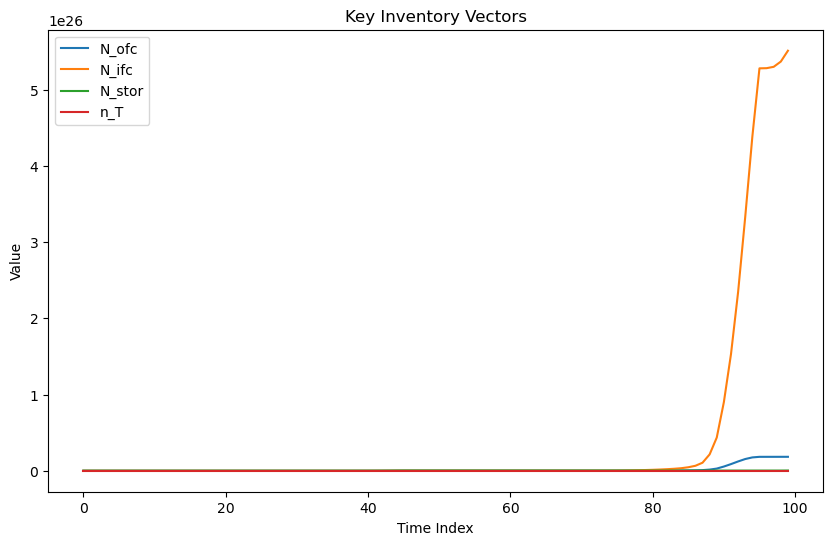

In [5]:
# 5. Display and Analyze Results
import pprint
pp = pprint.PrettyPrinter(indent=2)
print("Result dictionary from compute_single_combination:")
pp.pprint(result)

# Optionally plot key results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(result['N_ofc'], label='N_ofc')
plt.plot(result['N_ifc'], label='N_ifc')
plt.plot(result['N_stor'], label='N_stor')
plt.plot(result['n_T'], label='n_T')
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.title('Key Inventory Vectors')
plt.legend()
plt.show()